In [10]:
%pip install folium

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('pohang_food_stores.csv', encoding='utf-8')
df = df.dropna(subset=['latitude', 'longitude'])

In [5]:
lat = df['latitude'].mean()
lon = df['longitude'].mean()

m = folium.Map(location=[lat, lon], zoom_start=12)
marker_cluster = MarkerCluster().add_to(m)

color_dict = {
    '한식': 'red',
    '카페/디저트': 'orange',
    '분식/패스트푸드': 'lightred',
    '주점': 'purple',
    '중식': 'green',
    '일식': 'blue',
    '양식/외국식': 'darkblue'
}

for i, row in df.iterrows():
    cat = str(row['category_group'])
    
    if cat in color_dict:
        color = color_dict[cat]
    else:
        color = 'gray'
    
    info_text = f"{row['store_name']} [{cat}]"
    
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=info_text,
        icon=folium.Icon(color=color)
    ).add_to(marker_cluster)

m.save('pohang_food_map.html')

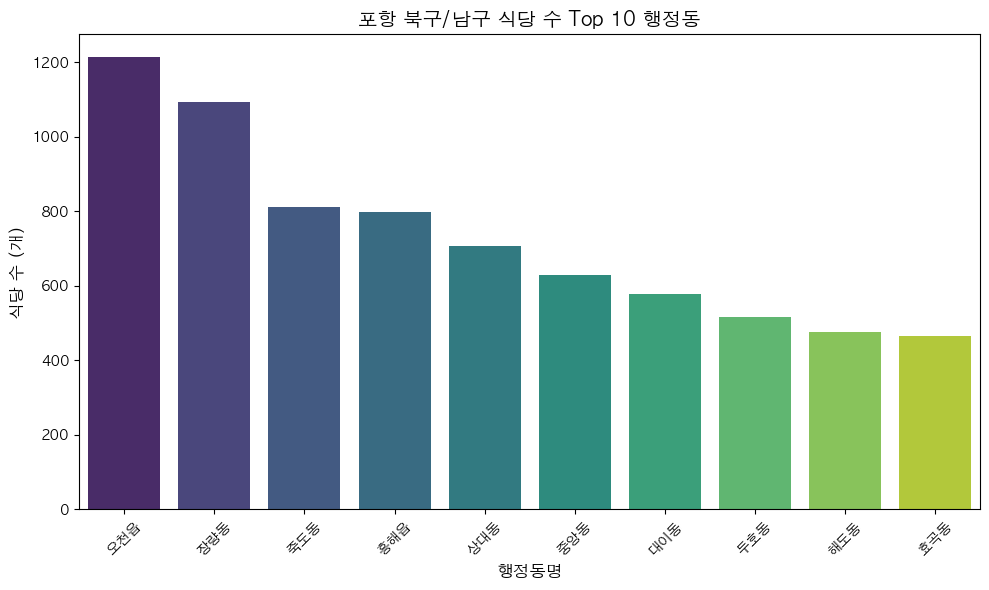

In [7]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

dong_counts = df['dong'].value_counts().head(10)

top10_dongs = dong_counts.index
df_top10 = df[df['dong'].isin(top10_dongs)]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=dong_counts.index, 
    y=dong_counts.values, 
    palette='viridis',
    hue=dong_counts.index,
    legend=False
)

plt.title('포항 북구/남구 식당 수 Top 10 행정동', fontsize=14, fontweight='bold')
plt.xlabel('행정동명', fontsize=12)
plt.ylabel('식당 수 (개)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('dong_top10_count.png', dpi=300)
plt.show()

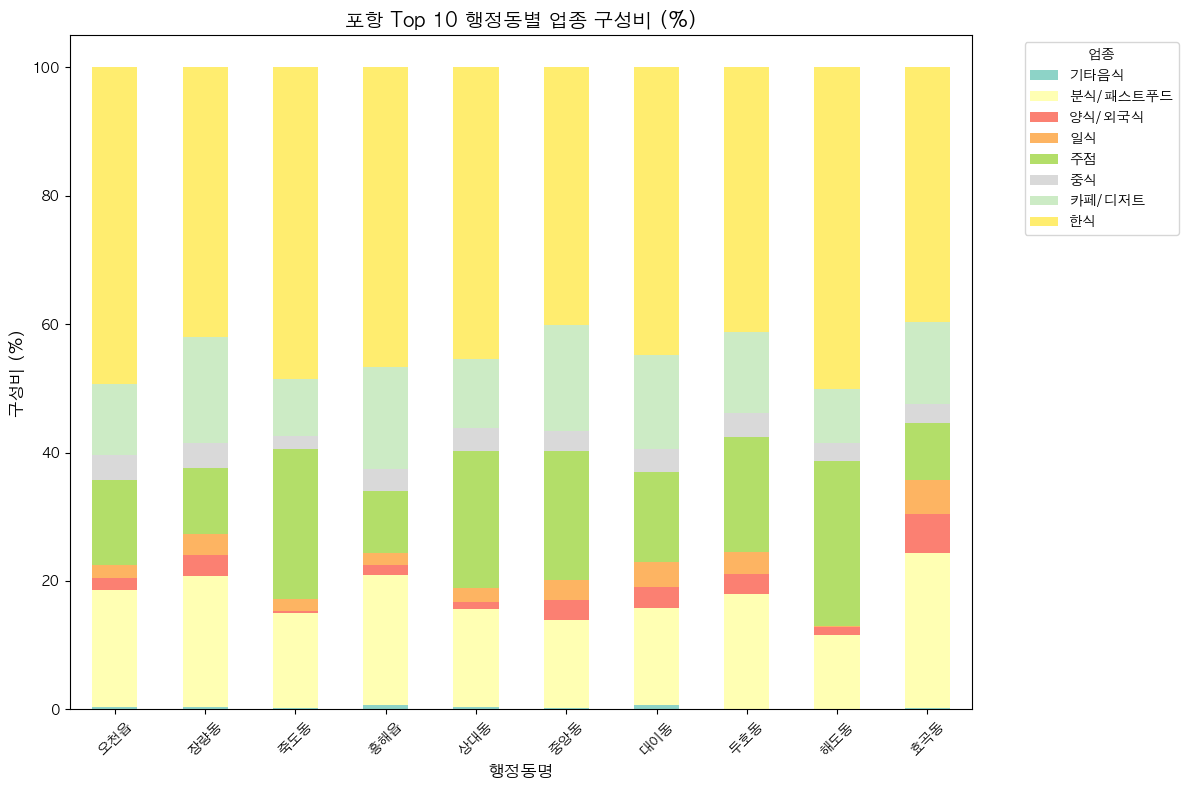

In [4]:
pivot = df_top10.groupby(['dong', 'category_group']).size().unstack(fill_value=0)
pivot = pivot.loc[top10_dongs]

ratio = pivot.div(pivot.sum(axis=1), axis=0) * 100

ratio.plot(kind='bar', stacked=True, figsize=(12, 8), cmap='Set3')

plt.title('포항 Top 10 행정동별 업종 구성비 (%)', fontsize=14, fontweight='bold')
plt.xlabel('행정동명', fontsize=12)
plt.ylabel('구성비 (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='업종', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('dong_category_ratio.png', dpi=300)
plt.show()